In [1]:
"""
ML Pipeline for MRoS probabilistic binary precipitation-phase prediction using
raw MRoS labels, interpolated predictor surfaces, and leakage-safe LOOCV MRoS
support indicators.

This refactored version keeps the same preprocessing, sampling, and spatial
blocking workflow as the multiclass notebook, but changes the supervised task to
binary rain-vs-snow classification with post-hoc probability calibration and an
uncertainty-derived mix / transition product.

Scientific intent
-----------------
1. Raw MRoS categorical observations remain the only supervised-learning labels.
2. The supervised target is binary only for observed pure-phase cases:
      rain vs snow.
3. Observed mix is *not* forced to be a crisp learnable class during fitting.
4. XGBoost outputs rain/snow probabilities, which are then calibrated on the
   validation pure-phase subset using a simple sigmoid / Platt-scaling step.
5. A transition / uncertainty band on calibrated snow probability is used to
   derive a final 3-class rain / mix / snow product on the full validation and
   test sets.
6. LOOCV-safe MRoS support indicators are retained as predictors only, never as
   labels.

Interpretation
--------------
- p_snow_cal and p_rain_cal are calibrated model-estimated probabilities.
- transition_score summarizes ambiguity between rain and snow.
- predicted_mix is derived from the uncertainty band; it is not a directly
  supervised class.
"""

from __future__ import annotations

import json
import pickle
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xgboost as xgb
from scipy.stats import entropy
from sklearn.utils.class_weight import compute_class_weight

# =============================================================================
# CONFIG
# =============================================================================

BASE_DIR = Path().resolve().parent
print("BASE_DIR:", BASE_DIR)

ML_DIR = BASE_DIR / "ML_pipeline"
ML_DIR.mkdir(exist_ok=True)
print("ML_DIR:", ML_DIR)

DATA_DIR = Path(r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs")
print("DATA_DIR:", DATA_DIR)

interp_type = "IDW"   # "IDW" or "kriging"

PATHS = {
    "IDW": {
        "interp_grid": DATA_DIR / "hourly_pipeline/IDW_refactored/hourly_predictors_1km_IDW.nc",
        "mros_loocv": DATA_DIR / "hourly_pipeline/IDW_refactored/mros_loocv_point_predictions_IDW.parquet",
    },
    "kriging": {
        "interp_grid": DATA_DIR / "hourly_pipeline/indicator_kriging_refactored/hourly_predictors_1km_indicator_kriging.nc",
        "mros_loocv": DATA_DIR / "hourly_pipeline/indicator_kriging_refactored/mros_loocv_point_predictions_kriging.parquet",
    },
    "imerg": DATA_DIR / "resampled_grids/imerg_hourly_1km.nc",
    "prism": DATA_DIR / "resampled_grids/prism_hourly_1km.nc",
}

if interp_type not in {"IDW", "kriging"}:
    raise ValueError(f"Unknown interp_type: {interp_type}")

interp_type_folder = "withIDW_v5_binary_uncertainty" if interp_type == "IDW" else "withKriging_v5_binary_uncertainty"

SETUP_DIR = DATA_DIR / "ML_pipeline/compiled_input_predictors" / interp_type_folder
SETUP_DIR.mkdir(parents=True, exist_ok=True)
print("SETUP_DIR:", SETUP_DIR)

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

GRAPHICS_DIR = MODEL_OUT_DIR / "graphics"
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
print("GRAPHICS_DIR:", GRAPHICS_DIR)

# spatial blocking
BLOCK_SIZE_M = 25_000
MIN_BLOCK_SAMPLES = 30
RANDOM_SEED = 42

# model settings
EARLY_STOPPING_ROUNDS = 50
NUM_BOOST_ROUND = 2000
TRANSITION_ALPHA = 1.0

# probabilistic binary -> uncertainty-derived mix settings
SNOW_CODE = 0
RAIN_CODE = 1
MIX_CODE = 2
BINARY_LABEL_MAP = {RAIN_CODE: 0, SNOW_CODE: 1}   # 0=rain, 1=snow for binary fitting
BINARY_LABEL_NAMES = ["rain", "snow"]
FULL_CLASS_NAMES = ["snow", "rain", "mix"]
RAIN_PROB_THRESHOLD = 0.30   # p_snow <= this => rain
SNOW_PROB_THRESHOLD = 0.70   # p_snow >= this => snow
CALIBRATION_METHOD = "sigmoid"   # simple Platt-style logistic calibration
APPLY_TRANSITION_WEIGHT = False   # keep default simple / defensible

# ---------------------------------------------------------------------
# Feature toggles
# ---------------------------------------------------------------------
USE_TEMP_AIR = True
USE_PRISM_TAIR = True
USE_TEMP_DEW = True
USE_TEMP_WET = True
USE_RH = True
USE_IMERG_PLP = True
USE_ELEV = True
USE_MROS_LOOCV = True

# Optional diagnostics
RUN_CORR_DIAGNOSTICS = True


BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
DATA_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs
SETUP_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v5_binary_uncertainty
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v5_binary_uncertainty
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v5_binary_uncertainty\graphics


In [2]:
# =============================================================================
# HELPERS
# =============================================================================

from pyproj import Transformer

PHASE_NAME_TO_CODE = {
    "snow": 0,
    "rain": 1,
    "mix": 2,
    "mixed": 2,
    "mixed_phase": 2,
}
PHASE_CODE_TO_NAME = {0: "snow", 1: "rain", 2: "mix"}


def summarize_time(ds: xr.Dataset, name: str) -> None:
    t = pd.to_datetime(ds["time"].values)
    print(f"\n{name} time summary:")
    print("  start:", t.min())
    print("  end:  ", t.max())
    print("  n:", len(t))
    print("  freq guess:", pd.infer_freq(t[: min(10, len(t))]))


def summarize_grid(ds: xr.Dataset, name: str) -> None:
    print(f"\n{name} grid summary:")
    for dim in ["x", "y"]:
        vals = ds[dim].values
        step = np.mean(np.diff(vals)) if len(vals) > 1 else np.nan
        print(f"  {dim}: n={len(vals)}, min={vals.min():.2f}, max={vals.max():.2f}, d≈{step:.2f}")


def candidate_column(df: pd.DataFrame, names: Iterable[str], label: str) -> str:
    for n in names:
        if n in df.columns:
            return n
    raise KeyError(f"Could not find {label}. Tried: {list(names)}")


def optional_column(df: pd.DataFrame, names: Iterable[str]) -> Optional[str]:
    for n in names:
        if n in df.columns:
            return n
    return None


def normalize_phase_value(v) -> Optional[int]:
    if pd.isna(v):
        return None
    if isinstance(v, str):
        key = v.strip().lower()
        if key in PHASE_NAME_TO_CODE:
            return PHASE_NAME_TO_CODE[key]
        try:
            iv = int(float(key))
            if iv in PHASE_CODE_TO_NAME:
                return iv
        except Exception:
            return None
        return None
    try:
        iv = int(v)
        if iv in PHASE_CODE_TO_NAME:
            return iv
    except Exception:
        return None
    return None


def get_dataset_crs(ds: xr.Dataset, fallback: str = "EPSG:26911"):
    # Prefer rioxarray CRS if present
    try:
        if hasattr(ds, "rio") and ds.rio.crs is not None:
            return ds.rio.crs
    except Exception:
        pass

    # Try attrs as backup
    for key in ["crs", "spatial_ref"]:
        if key in ds.attrs and ds.attrs[key]:
            return ds.attrs[key]

    return fallback


def project_lonlat_to_grid(
    lon: np.ndarray,
    lat: np.ndarray,
    grid_crs,
) -> tuple[np.ndarray, np.ndarray]:
    transformer = Transformer.from_crs("EPSG:4326", grid_crs, always_xy=True)
    x, y = transformer.transform(lon, lat)
    return np.asarray(x, dtype=float), np.asarray(y, dtype=float)


def prep_loocv_table(df: pd.DataFrame, ds_interp: xr.Dataset) -> pd.DataFrame:
    """
    Prepare raw MRoS LOOCV point table for ML.

    Expected refactored-IDW schema from parquet:
      - hour_utc
      - lon, lat
      - elev
      - obs_phase
      - mros_p_snow_loocv, mros_p_mix_loocv, mros_p_rain_loocv
    """
    df = df.copy()

    time_col = candidate_column(df, ["time", "hour_utc", "datetime", "timestamp"], "time column")

    # Refactored IDW LOOCV parquet is lon/lat based; projected x/y may be absent
    x_col = optional_column(df, ["x", "x_proj", "grid_x"])
    y_col = optional_column(df, ["y", "y_proj", "grid_y"])
    lon_col = optional_column(df, ["lon", "longitude", "x_lon"])
    lat_col = optional_column(df, ["lat", "latitude", "y_lat"])

    if (x_col is None or y_col is None) and (lon_col is None or lat_col is None):
        raise KeyError(
            "Could not find projected x/y columns or lon/lat columns in LOOCV parquet."
        )

    obs_col = candidate_column(
        df,
        ["observed_phase", "phase_obs", "raw_phase", "phase", "obs_phase", "phase_label"],
        "observed phase column",
    )
    snow_col = candidate_column(
        df,
        ["mros_p_snow_loocv", "p_snow_loocv", "p_snow_cv", "p_snow"],
        "LOOCV snow probability column",
    )
    mix_col = candidate_column(
        df,
        ["mros_p_mix_loocv", "p_mix_loocv", "p_mix_cv", "p_mix"],
        "LOOCV mix probability column",
    )
    rain_col = candidate_column(
        df,
        ["mros_p_rain_loocv", "p_rain_loocv", "p_rain_cv", "p_rain"],
        "LOOCV rain probability column",
    )

    out = pd.DataFrame({
        "time": pd.to_datetime(df[time_col], errors="coerce", utc=True).dt.floor("h").dt.tz_localize(None),
        "phase_full": df[obs_col].map(normalize_phase_value),
        "mros_p_snow_loocv": pd.to_numeric(df[snow_col], errors="coerce"),
        "mros_p_mix_loocv": pd.to_numeric(df[mix_col], errors="coerce"),
        "mros_p_rain_loocv": pd.to_numeric(df[rain_col], errors="coerce"),
    })

    # Keep lon/lat if available
    if lon_col is not None:
        out["lon"] = pd.to_numeric(df[lon_col], errors="coerce")
    if lat_col is not None:
        out["lat"] = pd.to_numeric(df[lat_col], errors="coerce")

    # Prefer existing projected coordinates if already present
    if x_col is not None and y_col is not None:
        out["x"] = pd.to_numeric(df[x_col], errors="coerce")
        out["y"] = pd.to_numeric(df[y_col], errors="coerce")
    else:
        grid_crs = get_dataset_crs(ds_interp, fallback="EPSG:26911")
        x_proj, y_proj = project_lonlat_to_grid(
            out["lon"].to_numpy(dtype=float),
            out["lat"].to_numpy(dtype=float),
            grid_crs=grid_crs,
        )
        out["x"] = x_proj
        out["y"] = y_proj

    # Preserve optional metadata from IDW LOOCV export
    optional_cols = [
        "hour_utc",
        "elev",
        "pred_phase",
        "obs_p_snow",
        "obs_p_mix",
        "obs_p_rain",
        "pred_max_prob",
        "pred_entropy",
        "pred_correct",
        "station_id",
        "obs_id",
        "source",
    ]
    for c in optional_cols:
        if c in df.columns and c not in out.columns:
            out[c] = df[c]
            
    # Preserve raw observation elevation under a distinct name
    if "elev" in df.columns and "obs_elev" not in out.columns:
        out["obs_elev"] = pd.to_numeric(df["elev"], errors="coerce")

    out["phase_full"] = out["phase_full"].astype("Int64")

    # Renormalize LOOCV probabilities defensively
    probs = out[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].to_numpy(dtype=float)
    probs = np.clip(probs, 0.0, 1.0)
    row_sum = probs.sum(axis=1)
    valid = row_sum > 0
    probs[valid] = probs[valid] / row_sum[valid, None]
    probs[~valid] = np.nan
    out[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]] = probs

    out = out.dropna(subset=[
        "time", "x", "y", "phase_full",
        "mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv",
    ]).copy()

    out["phase_full"] = out["phase_full"].astype(int)
    return out

def build_predictor_cube(
    ds_interp: xr.Dataset,
    ds_imerg: xr.Dataset,
    ds_prism: xr.Dataset,
    use_temp_air: bool = True,
    use_temp_dew: bool = True,
    use_temp_wet: bool = True,
    use_rh: bool = True,
    use_elev: bool = True,
    use_imerg_plp: bool = True,
    use_prism_tair: bool = True,
    use_prism_tmean: bool = False,
    use_prism_tdmean: bool = False,
    use_prism_ppt: bool = False,
) -> xr.Dataset:
    """
    Build one aligned predictor cube on common (time, y, x).
    """
    interp_keep = []
    if use_temp_air and "temp_air" in ds_interp:
        interp_keep.append("temp_air")
    if use_temp_dew and "temp_dew" in ds_interp:
        interp_keep.append("temp_dew")
    if use_temp_wet and "temp_wet" in ds_interp:
        interp_keep.append("temp_wet")
    if use_rh and "rh" in ds_interp:
        interp_keep.append("rh")
    if use_elev and "elev" in ds_interp:
        interp_keep.append("elev")

    imerg_keep = []
    if use_imerg_plp and "imerg_plp" in ds_imerg:
        imerg_keep.append("imerg_plp")

    prism_keep = []
    if use_prism_tair and "prism_tair" in ds_prism:
        prism_keep.append("prism_tair")
    if use_prism_tmean and "prism_tmean" in ds_prism:
        prism_keep.append("prism_tmean")
    if use_prism_tdmean and "prism_tdmean" in ds_prism:
        prism_keep.append("prism_tdmean")
    if use_prism_ppt and "prism_ppt" in ds_prism:
        prism_keep.append("prism_ppt")

    parts = []
    if interp_keep:
        parts.append(ds_interp[interp_keep])
    if imerg_keep:
        parts.append(ds_imerg[imerg_keep])
    if prism_keep:
        parts.append(ds_prism[prism_keep])

    if not parts:
        raise ValueError("No predictor variables selected for predictor cube.")

    ds_pred = xr.merge(parts, compat="override", join="exact")
    return ds_pred

def nearest_index_1d(coord_vals: np.ndarray, query_vals: np.ndarray) -> np.ndarray:
    coord_vals = np.asarray(coord_vals)
    query_vals = np.asarray(query_vals)

    ascending = coord_vals[0] < coord_vals[-1]
    if not ascending:
        coord_work = coord_vals[::-1]
    else:
        coord_work = coord_vals

    idx = np.searchsorted(coord_work, query_vals)
    idx = np.clip(idx, 1, len(coord_work) - 1)

    left = coord_work[idx - 1]
    right = coord_work[idx]
    choose_right = np.abs(query_vals - right) < np.abs(query_vals - left)
    out = idx.copy()
    out[~choose_right] = idx[~choose_right] - 1

    if not ascending:
        out = (len(coord_vals) - 1) - out

    return out.astype(np.int64)


def sample_predictor_cube_to_points_batched(
    points_df: pd.DataFrame,
    ds_pred: xr.Dataset,
    predictor_vars: list[str],
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Sample one aligned predictor cube to raw MRoS observation points,
    processing one hour at a time.

    This only touches hourly slices that are actually present in points_df.
    """
    pts = points_df.copy().reset_index(drop=True)
    pts["time"] = pd.to_datetime(pts["time"]).dt.floor("h")

    # Keep only predictor vars that actually exist
    predictor_vars = [v for v in predictor_vars if v in ds_pred.data_vars]
    if not predictor_vars:
        raise ValueError("No valid predictor_vars found in ds_pred.")

    # Domain filter
    x_min, x_max = float(ds_pred["x"].min()), float(ds_pred["x"].max())
    y_min, y_max = float(ds_pred["y"].min()), float(ds_pred["y"].max())

    in_domain = (
        pts["x"].between(min(x_min, x_max), max(x_min, x_max)) &
        pts["y"].between(min(y_min, y_max), max(y_min, y_max))
    )
    if (~in_domain).any():
        print(f"Dropping {(~in_domain).sum()} rows outside predictor cube extent.")
        pts = pts.loc[in_domain].copy().reset_index(drop=True)

    # Precompute coordinate arrays
    tvals = pd.to_datetime(ds_pred["time"].values)
    xvals = ds_pred["x"].values
    yvals = ds_pred["y"].values

    # Map each point time to nearest time index in ds_pred
    point_time_int = pd.to_datetime(pts["time"]).to_numpy().astype("datetime64[ns]").astype("int64")
    ds_time_int = tvals.astype("datetime64[ns]").astype("int64")
    t_idx = nearest_index_1d(ds_time_int, point_time_int)

    pts["_t_idx"] = t_idx
    pts["_orig_row"] = np.arange(len(pts))

    sampled_chunks = []
    unique_tidx = np.sort(pts["_t_idx"].unique())

    if verbose:
        print(f"Sampling {len(pts)} points across {len(unique_tidx)} hourly slices...")

    for i, tidx in enumerate(unique_tidx, start=1):
        chunk = pts.loc[pts["_t_idx"] == tidx].copy()
        hour_val = tvals[tidx]

        if verbose and (i == 1 or i % 25 == 0 or i == len(unique_tidx)):
            print(f"  Hour batch {i}/{len(unique_tidx)}: {hour_val} ({len(chunk)} points)")

        # nearest x/y indices for this hour's points
        x_idx = nearest_index_1d(xvals, chunk["x"].to_numpy(dtype=float))
        y_idx = nearest_index_1d(yvals, chunk["y"].to_numpy(dtype=float))

        # Read only one 2D slice per variable for this hour
        sampled = pd.DataFrame(index=chunk.index)

        ds_hour = ds_pred.isel(time=int(tidx))

        for v in predictor_vars:
            arr2d = ds_hour[v].values  # shape: (y, x)
            sampled[v] = arr2d[y_idx, x_idx]

        chunk_out = pd.concat([chunk, sampled], axis=1)
        sampled_chunks.append(chunk_out)

    out = pd.concat(sampled_chunks, axis=0).sort_values("_orig_row").reset_index(drop=True)
    out = out.drop(columns=["_t_idx", "_orig_row"])

    return out

def add_spatial_blocks(df: pd.DataFrame, block_size_m: int) -> pd.DataFrame:
    out = df.copy()
    out["block_x"] = np.floor(out["x"] / block_size_m).astype(np.int32)
    out["block_y"] = np.floor(out["y"] / block_size_m).astype(np.int32)
    out["block_id"] = list(zip(out["block_x"], out["block_y"]))
    return out


def assign_block_splits(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    out = df.copy()
    rng = np.random.default_rng(seed)
    blocks = np.array(out["block_id"].unique(), dtype=object)
    rng.shuffle(blocks)

    n_blocks = len(blocks)
    n_train = int(0.70 * n_blocks)
    n_val = int(0.15 * n_blocks)

    train_blocks = set(blocks[:n_train])
    val_blocks = set(blocks[n_train:n_train + n_val])
    test_blocks = set(blocks[n_train + n_val:])

    def _assign(bid):
        if bid in train_blocks:
            return "train"
        if bid in val_blocks:
            return "val"
        return "test"

    out["split"] = out["block_id"].map(_assign)
    return out


def build_blocked_split_df(
    points_df: pd.DataFrame,
    block_size_m: int,
    min_block_samples: int,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Add spatial blocks, filter undersampled blocks, and assign train/val/test splits.
    Returns a new DataFrame without modifying the input.
    """
    blocked_df = add_spatial_blocks(points_df.copy(), block_size_m)

    block_counts = blocked_df["block_id"].value_counts()
    keep_blocks = block_counts[block_counts >= min_block_samples].index

    blocked_df = blocked_df[blocked_df["block_id"].isin(keep_blocks)].copy()

    if blocked_df.empty:
        return blocked_df

    blocked_df = assign_block_splits(blocked_df, seed=seed)
    return blocked_df


def summarize_blocked_split(
    blocked_df: pd.DataFrame,
    original_df: pd.DataFrame,
    block_size_m: int,
    min_block_samples: int,
) -> dict:
    """
    Summarize one blocked configuration for comparison across candidate block sizes.
    """
    n_blocks_before = add_spatial_blocks(original_df.copy(), block_size_m)["block_id"].nunique()
    n_blocks_after = blocked_df["block_id"].nunique() if not blocked_df.empty else 0

    frac_rows_kept = len(blocked_df) / len(original_df) if len(original_df) else np.nan

    result = {
        "block_size_m": block_size_m,
        "min_block_samples": min_block_samples,
        "rows_total": len(original_df),
        "rows_kept": len(blocked_df),
        "frac_rows_kept": frac_rows_kept,
        "blocks_before": n_blocks_before,
        "blocks_after": n_blocks_after,
        "min_block_count": np.nan,
        "median_block_count": np.nan,
        "max_block_count": np.nan,
        "train_frac": np.nan,
        "val_frac": np.nan,
        "test_frac": np.nan,
        "train_snow": np.nan,
        "train_rain": np.nan,
        "train_mix": np.nan,
        "val_snow": np.nan,
        "val_rain": np.nan,
        "val_mix": np.nan,
        "test_snow": np.nan,
        "test_rain": np.nan,
        "test_mix": np.nan,
        "score": -np.inf,
    }

    if blocked_df.empty:
        return result

    block_sizes = blocked_df["block_id"].value_counts()
    result["min_block_count"] = block_sizes.min()
    result["median_block_count"] = block_sizes.median()
    result["max_block_count"] = block_sizes.max()

    split_props = blocked_df["split"].value_counts(normalize=True)
    result["train_frac"] = split_props.get("train", 0.0)
    result["val_frac"] = split_props.get("val", 0.0)
    result["test_frac"] = split_props.get("test", 0.0)

    class_balance = (
        blocked_df.groupby("split")["phase_full"]
        .value_counts(normalize=True)
        .unstack(fill_value=0.0)
    )

    # columns are 0=snow, 1=rain, 2=mix
    result["train_snow"] = class_balance.loc["train", 0] if "train" in class_balance.index and 0 in class_balance.columns else np.nan
    result["train_rain"] = class_balance.loc["train", 1] if "train" in class_balance.index and 1 in class_balance.columns else np.nan
    result["train_mix"]  = class_balance.loc["train", 2] if "train" in class_balance.index and 2 in class_balance.columns else np.nan

    result["val_snow"] = class_balance.loc["val", 0] if "val" in class_balance.index and 0 in class_balance.columns else np.nan
    result["val_rain"] = class_balance.loc["val", 1] if "val" in class_balance.index and 1 in class_balance.columns else np.nan
    result["val_mix"]  = class_balance.loc["val", 2] if "val" in class_balance.index and 2 in class_balance.columns else np.nan

    result["test_snow"] = class_balance.loc["test", 0] if "test" in class_balance.index and 0 in class_balance.columns else np.nan
    result["test_rain"] = class_balance.loc["test", 1] if "test" in class_balance.index and 1 in class_balance.columns else np.nan
    result["test_mix"]  = class_balance.loc["test", 2] if "test" in class_balance.index and 2 in class_balance.columns else np.nan

    # Simple heuristic score:
    # favor more retained blocks, more retained rows, and split proportions near 70/15/15
    target = {"train": 0.70, "val": 0.15, "test": 0.15}
    split_penalty = (
        abs(result["train_frac"] - target["train"]) +
        abs(result["val_frac"] - target["val"]) +
        abs(result["test_frac"] - target["test"])
    )

    # penalize very few retained blocks
    block_bonus = result["blocks_after"]

    # penalize class imbalance between train and val/test (snow/rain/mix only where available)
    class_penalty = 0.0
    for cls in ["snow", "rain", "mix"]:
        tr = result.get(f"train_{cls}", np.nan)
        va = result.get(f"val_{cls}", np.nan)
        te = result.get(f"test_{cls}", np.nan)
        if pd.notna(tr) and pd.notna(va):
            class_penalty += abs(tr - va)
        if pd.notna(tr) and pd.notna(te):
            class_penalty += abs(tr - te)

    result["score"] = (
        3.0 * result["frac_rows_kept"]
        + 0.10 * block_bonus
        - 2.0 * split_penalty
        - 1.5 * class_penalty
    )

    return result


def evaluate_block_sizes(
    points_df: pd.DataFrame,
    block_sizes_m: list[int],
    min_block_samples: int,
    seed: int = 42,
) -> tuple[pd.DataFrame, dict]:
    """
    Try several block sizes and return:
      - block_eval_df: one-row summary per block size
      - blocked_versions: dict of block_size -> blocked DataFrame
    """
    summaries = []
    blocked_versions = {}

    for bs in block_sizes_m:
        blocked_df = build_blocked_split_df(
            points_df=points_df,
            block_size_m=bs,
            min_block_samples=min_block_samples,
            seed=seed,
        )
        blocked_versions[bs] = blocked_df

        summary = summarize_blocked_split(
            blocked_df=blocked_df,
            original_df=points_df,
            block_size_m=bs,
            min_block_samples=min_block_samples,
        )
        summaries.append(summary)

    block_eval_df = pd.DataFrame(summaries).sort_values(
        ["score", "blocks_after", "frac_rows_kept"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return block_eval_df, blocked_versions


def transition_weight(temp_wet: pd.Series, alpha: float) -> np.ndarray:
    tw = temp_wet.to_numpy(dtype=float)
    trans = (tw >= 0.0) & (tw <= 4.0)
    return 1.0 + alpha * trans.astype(float)

In [3]:
# =============================================================================
# READ DATA
# =============================================================================

interp_grid_path = PATHS[interp_type]["interp_grid"]
loocv_path = PATHS[interp_type]["mros_loocv"]
imerg_path = PATHS["imerg"]
prism_path = PATHS["prism"]

print("\nOpening datasets...")
ds_interp = xr.open_dataset(interp_grid_path)
ds_imerg = xr.open_dataset(imerg_path)
ds_prism = xr.open_dataset(prism_path)
df_loocv_raw = pd.read_parquet(loocv_path)

summarize_time(ds_interp, f"{interp_type} interpolation grid")
summarize_time(ds_imerg, "IMERG")
summarize_time(ds_prism, "PRISM")
summarize_grid(ds_interp, f"{interp_type} interpolation grid")


Opening datasets...

IDW interpolation grid time summary:
  start: 2024-10-01 00:00:00
  end:   2025-05-31 23:00:00
  n: 5832
  freq guess: h

IMERG time summary:
  start: 2024-10-11 00:00:00
  end:   2025-05-30 23:00:00
  n: 5160
  freq guess: D

PRISM time summary:
  start: 2024-10-11 00:00:00
  end:   2025-05-30 23:00:00
  n: 5160
  freq guess: D

IDW interpolation grid grid summary:
  x: n=142, min=162630.92, max=303630.92, d≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, d≈-1000.00


In [4]:
# =============================================================================
# TIME SYNCHRONIZATION
# =============================================================================

ds_interp = ds_interp.assign_coords(time=pd.to_datetime(ds_interp.time.values).floor("h"))
ds_imerg  = ds_imerg.assign_coords(time=pd.to_datetime(ds_imerg.time.values).floor("h"))
ds_prism  = ds_prism.assign_coords(time=pd.to_datetime(ds_prism.time.values).floor("h"))

common_times = np.intersect1d(ds_interp.time.values, ds_imerg.time.values)
common_times = np.intersect1d(common_times, ds_prism.time.values)

print("Common timesteps across interpolation, IMERG, and PRISM:", len(common_times))

ds_interp = ds_interp.sel(time=common_times)
ds_imerg  = ds_imerg.sel(time=common_times)
ds_prism  = ds_prism.sel(time=common_times)

Common timesteps across interpolation, IMERG, and PRISM: 5160


In [5]:
# =============================================================================
# BUILD ONE ALIGNED GRIDDED PREDICTOR CUBE
# =============================================================================

ds_pred = build_predictor_cube(
    ds_interp=ds_interp,
    ds_imerg=ds_imerg,
    ds_prism=ds_prism,
    use_temp_air=USE_TEMP_AIR,
    use_temp_dew=USE_TEMP_DEW,
    use_temp_wet=USE_TEMP_WET,
    use_rh=USE_RH,
    use_elev=USE_ELEV,
    use_imerg_plp=USE_IMERG_PLP,
    use_prism_tair=USE_PRISM_TAIR,
)

print(ds_pred)
print("Predictor variables in cube:", list(ds_pred.data_vars))

<xarray.Dataset> Size: 6GB
Dimensions:     (time: 5160, y: 251, x: 142)
Coordinates:
  * y           (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x           (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time        (time) datetime64[ns] 41kB 2024-10-11 ... 2025-05-30T23:00:00
Data variables:
    temp_air    (time, y, x) float32 736MB ...
    temp_dew    (time, y, x) float32 736MB ...
    temp_wet    (time, y, x) float32 736MB ...
    rh          (time, y, x) float32 736MB ...
    elev        (y, x) float32 143kB ...
    imerg_plp   (time, y, x) float64 1GB ...
    prism_tair  (time, y, x) float64 1GB ...
Attributes:
    title:                             Hourly predictor stacks on 1-km grid (...
    continuous_vars_elevation_method:  dynamic lapse detrend/retrend
    mros_elevation_method:             3D IDW distance metric with vertical s...
    mros_vertical_scale:               4.0
    idw_power:                         2.0
    k_nearest:       

In [6]:
# =============================================================================
# PREP LOOCV-POINT TABLE (RAW LABELS + LEAKAGE-SAFE MROS PREDICTORS)
# =============================================================================

loocv_df = prep_loocv_table(df_loocv_raw, ds_interp=ds_pred)

print("\nLOOCV point table columns:")
print(loocv_df.columns.tolist())
print("LOOCV class counts:")
print(loocv_df["phase_full"].value_counts(dropna=False).sort_index())

loocv_df = loocv_df[loocv_df["time"].isin(pd.to_datetime(common_times))].copy()
print("Rows after time intersection:", len(loocv_df))



LOOCV point table columns:
['time', 'phase_full', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv', 'lon', 'lat', 'x', 'y', 'hour_utc', 'elev', 'pred_phase', 'obs_p_snow', 'obs_p_mix', 'obs_p_rain', 'pred_max_prob', 'pred_entropy', 'pred_correct', 'obs_elev']
LOOCV class counts:
phase_full
0    3447
1    2647
2     845
Name: count, dtype: int64
Rows after time intersection: 6198


In [7]:
FEATURES = []

if USE_TEMP_AIR:
    FEATURES.append("temp_air")
if USE_PRISM_TAIR:
    FEATURES.append("prism_tair")
if USE_TEMP_DEW:
    FEATURES.append("temp_dew")
if USE_TEMP_WET:
    FEATURES.append("temp_wet")
if USE_RH:
    FEATURES.append("rh")
if USE_IMERG_PLP:
    FEATURES.append("imerg_plp")
if USE_ELEV:
    FEATURES.append("elev")

grid_features = FEATURES.copy()

if USE_MROS_LOOCV:
    FEATURES.extend([
        "mros_p_snow_loocv",
        "mros_p_mix_loocv",
        "mros_p_rain_loocv",
    ])

In [8]:
# =============================================================================
# SAMPLE GRIDDED PREDICTOR CUBE TO RAW MROS OBSERVATION POINTS
# =============================================================================

master_df = sample_predictor_cube_to_points_batched(
    loocv_df,
    ds_pred=ds_pred,
    predictor_vars=grid_features,
    verbose=True,
)

Dropping 48 rows outside predictor cube extent.
Sampling 6150 points across 577 hourly slices...
  Hour batch 1/577: 2024-10-16 17:00:00 (4 points)
  Hour batch 25/577: 2024-11-11 18:00:00 (8 points)
  Hour batch 50/577: 2024-11-18 03:00:00 (3 points)
  Hour batch 75/577: 2024-11-22 17:00:00 (5 points)
  Hour batch 100/577: 2024-11-23 21:00:00 (18 points)
  Hour batch 125/577: 2024-11-26 21:00:00 (9 points)
  Hour batch 150/577: 2024-12-14 08:00:00 (3 points)
  Hour batch 175/577: 2024-12-21 20:00:00 (8 points)
  Hour batch 200/577: 2024-12-26 18:00:00 (13 points)
  Hour batch 225/577: 2024-12-29 23:00:00 (19 points)
  Hour batch 250/577: 2025-01-25 19:00:00 (3 points)
  Hour batch 275/577: 2025-01-31 19:00:00 (33 points)
  Hour batch 300/577: 2025-02-02 02:00:00 (10 points)
  Hour batch 325/577: 2025-02-04 18:00:00 (28 points)
  Hour batch 350/577: 2025-02-07 03:00:00 (9 points)
  Hour batch 375/577: 2025-02-13 20:00:00 (23 points)
  Hour batch 400/577: 2025-02-16 19:00:00 (4 points)


In [ ]:
required_predictors = FEATURES.copy()

missing_required = [c for c in required_predictors + ["phase_full"] if c not in master_df.columns]
if missing_required:
    raise KeyError(f"Missing required columns after predictor assembly: {missing_required}")

master_df = master_df.dropna(subset=required_predictors + ["phase_full"]).copy()
master_df["phase_full"] = master_df["phase_full"].astype(int)

print("\nMaster table shape after sampling + dropna:", master_df.shape)
print("Class balance before blocking:")
print(master_df["phase_full"].value_counts(normalize=True).sort_index())

assembled_parquet = SETUP_DIR / f"ml_input_points_{interp_type}_binary_uncertainty.parquet"

master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()

master_df.to_parquet(assembled_parquet, index=False)
print("Saved assembled pointwise ML table to:", assembled_parquet)



Master table shape after sampling + dropna: (6150, 26)
Class balance before blocking:
phase_full
0    0.481626
1    0.398537
2    0.119837
Name: proportion, dtype: float64
Saved assembled pointwise ML table to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v5_binary_uncertainty\ml_input_points_IDW_binary_uncertainty.parquet


In [11]:
# =============================================================================
# SPATIAL BLOCKING
# =============================================================================
"""
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes meaningless for true spatial generalization
- Approach: use autocorrelation and application logic to choose a plausible block-size range, then test several sizes rather than assuming one is correct.
"""
# -- pull back in original saved version
assembled_parquet = SETUP_DIR / f"ml_input_points_{interp_type}_binary_uncertainty.parquet"
points_ml_df = pd.read_parquet(assembled_parquet)

print(points_ml_df.shape)
print(points_ml_df.columns.tolist())
print(points_ml_df["phase_full"].value_counts(normalize=True).sort_index())
# ---


# =============================================================================
# SPATIAL BLOCKING SENSITIVITY TEST
# =============================================================================
"""
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes misleading for true spatial generalization
- Use autocorrelation and application logic to choose a plausible block-size range,
  then test several sizes rather than assuming one is correct.
"""

BLOCK_SIZE_CANDIDATES_M = [BLOCK_SIZE_M, int(BLOCK_SIZE_M * 1.5), BLOCK_SIZE_M * 2, BLOCK_SIZE_M * 3]

block_eval_df, blocked_versions = evaluate_block_sizes(
    points_df=points_ml_df,
    block_sizes_m=BLOCK_SIZE_CANDIDATES_M,
    min_block_samples=MIN_BLOCK_SAMPLES,
    seed=RANDOM_SEED,
)

print(block_eval_df[[
    "block_size_m",
    "rows_kept",
    "frac_rows_kept",
    "blocks_before",
    "blocks_after",
    "min_block_count",
    "median_block_count",
    "train_frac",
    "val_frac",
    "test_frac",
    "score",
]])


(6150, 25)
['time', 'phase_full', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv', 'lon', 'lat', 'x', 'y', 'hour_utc', 'elev', 'pred_phase', 'obs_p_snow', 'obs_p_mix', 'obs_p_rain', 'pred_max_prob', 'pred_entropy', 'pred_correct', 'obs_elev', 'temp_air', 'prism_tair', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp']
phase_full
0    0.481626
1    0.398537
2    0.119837
Name: proportion, dtype: float64
   block_size_m  rows_kept  frac_rows_kept  blocks_before  blocks_after  \
0         25000       5940        0.965854             42            18   
1         37500       6033        0.980976             24            16   
2         50000       6144        0.999024             14            11   
3         75000       6109        0.993333              8             6   

   min_block_count  median_block_count  train_frac  val_frac  test_frac  \
0               49               213.5    0.612458  0.181313   0.206229   
1               31               180.5    0.702801  0.245980   

In [12]:
# =============================================================================
# SELECT BEST BLOCK SIZE
# =============================================================================

best_block_size_m = int(block_eval_df.iloc[0]["block_size_m"])
best_blocked_df = blocked_versions[best_block_size_m].copy()

print(f"Selected block size: {best_block_size_m} m")
print("Best blocked table shape:", best_blocked_df.shape)

print("\nSplit proportions:")
print(best_blocked_df["split"].value_counts(normalize=True))

print("\nClass balance by split:")
print(
    best_blocked_df.groupby("split")["phase_full"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
)

blocked_parquet = SETUP_DIR / f"ml_input_points_{interp_type}_binary_uncertainty_blocked_best.parquet"
best_blocked_df.to_parquet(blocked_parquet, index=False)
print("Saved blocked ML table to:", blocked_parquet)


Selected block size: 25000 m
Best blocked table shape: (5940, 29)

Split proportions:
split
train    0.612458
test     0.206229
val      0.181313
Name: proportion, dtype: float64

Class balance by split:
phase_full         0         1         2
split                                   
test        0.522449  0.369796  0.107755
train       0.444475  0.428257  0.127268
val         0.588672  0.313835  0.097493
Saved blocked ML table to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v5_binary_uncertainty\ml_input_points_IDW_binary_uncertainty_blocked_best.parquet


In [13]:
# =============================================================================
# PLOT CHOSEN BLOCK SPLIT
# =============================================================================

block_centers_df = (
    best_blocked_df.groupby("block_id")
    .agg(
        x_mean=("x", "mean"),
        y_mean=("y", "mean"),
        split=("split", "first"),
        n=("phase_full", "size"),
    )
    .reset_index()
)

colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:red"}

fig, ax = plt.subplots(figsize=(10, 8))
dem = ds_interp["elev"]
dem_vals = dem.values
extent = [float(dem["x"].min()), float(dem["x"].max()), float(dem["y"].min()), float(dem["y"].max())]
origin = "upper" if float(dem["y"][0]) > float(dem["y"][-1]) else "lower"

im = ax.imshow(dem_vals, extent=extent, origin=origin, cmap="terrain", alpha=0.6)

for split, g in block_centers_df.groupby("split"):
    ax.scatter(
        g["x_mean"],
        g["y_mean"],
        s=40,
        c=colors[split],
        label=split,
        alpha=0.9,
        edgecolor="k",
        linewidths=0.3,
    )

ax.legend(loc="upper left", bbox_to_anchor=(-0.2, 1.02), frameon=True)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Spatial block split over DEM ({interp_type}, block={best_block_size_m} m)")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="Elevation (m)")
fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"spatial_block_split_{interp_type}_{best_block_size_m}m.png",
    dpi=200,
    bbox_inches="tight",
)
plt.close(fig)

In [14]:
# =============================================================================
# FEATURE MATRICES
# =============================================================================

TARGET_FULL = "phase_full"
PURE_PHASE_CODES = [SNOW_CODE, RAIN_CODE]

train_df_full = best_blocked_df[best_blocked_df["split"] == "train"].copy()
val_df_full = best_blocked_df[best_blocked_df["split"] == "val"].copy()
test_df_full = best_blocked_df[best_blocked_df["split"] == "test"].copy()

train_df_fit = train_df_full[train_df_full[TARGET_FULL].isin(PURE_PHASE_CODES)].copy()
val_df_fit = val_df_full[val_df_full[TARGET_FULL].isin(PURE_PHASE_CODES)].copy()
test_df_fit = test_df_full[test_df_full[TARGET_FULL].isin(PURE_PHASE_CODES)].copy()

for name, df_ in [("train", train_df_fit), ("val", val_df_fit), ("test", test_df_fit)]:
    if df_.empty:
        raise ValueError(f"{name} pure-phase subset is empty. Cannot fit binary model.")

X_train = train_df_fit[FEATURES].copy()
X_val = val_df_fit[FEATURES].copy()
X_test = test_df_fit[FEATURES].copy()

X_val_full = val_df_full[FEATURES].copy()
X_test_full = test_df_full[FEATURES].copy()

# Binary labels used for fitting/calibration/evaluation on pure-phase only
# 0 = rain, 1 = snow

y_train = train_df_fit[TARGET_FULL].map(BINARY_LABEL_MAP).astype(int)
y_val = val_df_fit[TARGET_FULL].map(BINARY_LABEL_MAP).astype(int)
y_test = test_df_fit[TARGET_FULL].map(BINARY_LABEL_MAP).astype(int)

# Original 3-class labels retained for uncertainty-derived phase evaluation
y_val_full_phase = val_df_full[TARGET_FULL].astype(int).to_numpy()
y_test_full_phase = test_df_full[TARGET_FULL].astype(int).to_numpy()

y_val_fit_phase = val_df_fit[TARGET_FULL].astype(int).to_numpy()
y_test_fit_phase = test_df_fit[TARGET_FULL].astype(int).to_numpy()

print("\nTraining feature columns:")
print(FEATURES)

print("\nFull split counts (including observed mix):")
print("Train full counts:\n", train_df_full[TARGET_FULL].value_counts().sort_index())
print("Val full counts:\n", val_df_full[TARGET_FULL].value_counts().sort_index())
print("Test full counts:\n", test_df_full[TARGET_FULL].value_counts().sort_index())

print("\nPure-phase fitting counts (rain/snow only):")
print("Train fit counts:\n", train_df_fit[TARGET_FULL].value_counts().sort_index())
print("Val fit counts:\n", val_df_fit[TARGET_FULL].value_counts().sort_index())
print("Test fit counts:\n", test_df_fit[TARGET_FULL].value_counts().sort_index())

if RUN_CORR_DIAGNOSTICS:
    corr = train_df_fit[FEATURES].corr(numeric_only=True)
    corr.to_csv(MODEL_OUT_DIR / "predictor_correlation_matrix.csv")

    high_corr = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .reset_index()
    )
    high_corr.columns = ["var1", "var2", "correlation"]
    high_corr["abs_correlation"] = high_corr["correlation"].abs()
    high_corr = high_corr.sort_values("abs_correlation", ascending=False)

    high_corr.to_csv(MODEL_OUT_DIR / "predictor_correlation_pairs.csv", index=False)

    print("\nTop correlated predictor pairs:")
    print(high_corr.head(15))

# =============================================================================
# SAMPLE WEIGHTS
# =============================================================================

classes = np.array([0, 1])   # 0=rain, 1=snow
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight = dict(zip(classes, weights))
print("\nBalanced binary class weights:", class_weight)

w_train = y_train.map(class_weight).to_numpy(dtype=float)
w_val = y_val.map(class_weight).to_numpy(dtype=float)

if APPLY_TRANSITION_WEIGHT:
    w_train *= transition_weight(train_df_fit["temp_wet"], TRANSITION_ALPHA)
    w_val *= transition_weight(val_df_fit["temp_wet"], TRANSITION_ALPHA)
    print("Applied transition-window weighting to pure-phase subsets.")
else:
    print("Transition-window weighting disabled for this binary/uncertainty run.")

print("\nTraining weight summaries:")
print(pd.Series(w_train).describe())



Training feature columns:
['temp_air', 'prism_tair', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp', 'elev', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv']

Full split counts (including observed mix):
Train full counts:
 phase_full
0    1617
1    1558
2     463
Name: count, dtype: int64
Val full counts:
 phase_full
0    634
1    338
2    105
Name: count, dtype: int64
Test full counts:
 phase_full
0    640
1    453
2    132
Name: count, dtype: int64

Pure-phase fitting counts (rain/snow only):
Train fit counts:
 phase_full
0    1617
1    1558
Name: count, dtype: int64
Val fit counts:
 phase_full
0    634
1    338
Name: count, dtype: int64
Test fit counts:
 phase_full
0    640
1    453
Name: count, dtype: int64

Top correlated predictor pairs:
                 var1               var2  correlation  abs_correlation
2            temp_air           temp_wet     0.918453         0.918453
43  mros_p_snow_loocv  mros_p_rain_loocv    -0.856064         0.856064
17           temp_dew   

In [15]:
# =============================================================================
# FIT MODEL
# =============================================================================

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda": 1.0,
    "tree_method": "hist",
    "seed": RANDOM_SEED,
}

dtrain = xgb.DMatrix(
    X_train,
    label=y_train,
    weight=w_train,
    feature_names=FEATURES,
)

dval = xgb.DMatrix(
    X_val,
    label=y_val,
    weight=w_val,
    feature_names=FEATURES,
)

evals = [(dtrain, "train"), (dval, "val")]
evals_result = {}

booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    verbose_eval=50,
)

print("\nBest iteration:", booster.best_iteration)
print("Best validation score:", booster.best_score)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(evals_result["train"]["logloss"], label="train")
ax.plot(evals_result["val"]["logloss"], label="val")
ax.axvline(
    booster.best_iteration,
    ls="--",
    alpha=0.7,
    label=f"best={booster.best_iteration}",
)
ax.set_xlabel("Boosting iteration")
ax.set_ylabel("Binary log loss")
ax.set_title(f"XGBoost binary rain/snow logloss ({interp_type})")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"xgb_binary_logloss_{interp_type}.png",
    dpi=200,
    bbox_inches="tight",
)
plt.close(fig)


[0]	train-logloss:0.65886	val-logloss:0.66067
[50]	train-logloss:0.20815	val-logloss:0.26817
[100]	train-logloss:0.16064	val-logloss:0.24364
[147]	train-logloss:0.13952	val-logloss:0.24993

Best iteration: 97
Best validation score: 0.24250206946096106


In [16]:
# =============================================================================
# PREDICT / CALIBRATE / DERIVE UNCERTAINTY PRODUCT
# =============================================================================

"""
- Predicts raw binary model outputs
- Calibrates those outputs into better probabilities
- Derives an uncertainty-aware phase product from the calibrated probabilities
"""

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, log_loss

# Fit the post-hoc calibration model:
def platt_calibrate(margins: np.ndarray, y_true: np.ndarray) -> LogisticRegression:
    """
    Coneptually:
    - XGBoost: privdes internal rain/snow score
    - Platt scaling: given how those scores behaved on validation data, provides the probability that better matches observed frequency
    """
    model = LogisticRegression(solver="lbfgs", random_state=RANDOM_SEED)
    model.fit(margins.reshape(-1, 1), y_true)
    return model


def apply_platt(model: LogisticRegression, margins: np.ndarray) -> np.ndarray:
    return model.predict_proba(margins.reshape(-1, 1))[:, 1]


def transition_score_from_psnow(p_snow: np.ndarray) -> np.ndarray:
    """
    A simple ambiguity score on [0, 1].
    1.0 => maximally ambiguous (p_snow ~= 0.5)
    0.0 => very confident rain or snow
    """
    return 1.0 - np.abs(2.0 * p_snow - 1.0)

# Convert calibrated snow probability into a final 3-class phase label:
def classify_phase_with_uncertainty(
    p_snow: np.ndarray,
    rain_thresh: float,
    snow_thresh: float,
) -> np.ndarray:
    out = np.full(len(p_snow), MIX_CODE, dtype=int)
    out[p_snow <= rain_thresh] = RAIN_CODE
    out[p_snow >= snow_thresh] = SNOW_CODE
    return out


# ---------------------------------------------------------------------
# Pure-phase prediction sets used for binary evaluation / calibration
# ---------------------------------------------------------------------
dval_fit = xgb.DMatrix(X_val, feature_names=FEATURES)
dtest_fit = xgb.DMatrix(X_test, feature_names=FEATURES)

val_fit_margin_raw = booster.predict(dval_fit, output_margin=True)
val_fit_prob_raw = booster.predict(dval_fit)

test_fit_margin_raw = booster.predict(dtest_fit, output_margin=True)
test_fit_prob_raw = booster.predict(dtest_fit)

# ---------------------------------------------------------------------
# Post-hoc calibration on validation pure-phase subset only
# ---------------------------------------------------------------------
platt_model = platt_calibrate(val_fit_margin_raw, y_val.to_numpy())

val_fit_prob_cal = apply_platt(platt_model, val_fit_margin_raw)
test_fit_prob_cal = apply_platt(platt_model, test_fit_margin_raw)

print("\nCalibration model coefficients:")
print("coef:", float(platt_model.coef_[0, 0]))
print("intercept:", float(platt_model.intercept_[0]))

# ---------------------------------------------------------------------
# Full validation/test predictions for uncertainty-derived phase mapping
# ---------------------------------------------------------------------
dval_full = xgb.DMatrix(X_val_full, feature_names=FEATURES)
dtest_full = xgb.DMatrix(X_test_full, feature_names=FEATURES)

val_full_margin_raw = booster.predict(dval_full, output_margin=True)
val_full_prob_raw = booster.predict(dval_full)
val_full_prob_cal = apply_platt(platt_model, val_full_margin_raw)

test_full_margin_raw = booster.predict(dtest_full, output_margin=True)
test_full_prob_raw = booster.predict(dtest_full)
test_full_prob_cal = apply_platt(platt_model, test_full_margin_raw)

# Calibrated rain probabilities and uncertainty metrics
val_full_p_rain_cal = 1.0 - val_full_prob_cal
test_full_p_rain_cal = 1.0 - test_full_prob_cal
val_fit_p_rain_cal = 1.0 - val_fit_prob_cal
test_fit_p_rain_cal = 1.0 - test_fit_prob_cal

val_full_transition_score = transition_score_from_psnow(val_full_prob_cal)
test_full_transition_score = transition_score_from_psnow(test_full_prob_cal)
val_fit_transition_score = transition_score_from_psnow(val_fit_prob_cal)
test_fit_transition_score = transition_score_from_psnow(test_fit_prob_cal)

# Binary hard predictions on pure-phase subsets only
# phase code representation: snow=0, rain=1
val_fit_pred_binary05 = np.where(val_fit_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE)
test_fit_pred_binary05 = np.where(test_fit_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE)

# Uncertainty-derived 3-class predictions on full validation/test sets
val_full_pred_phase = classify_phase_with_uncertainty(
    val_full_prob_cal,
    rain_thresh=RAIN_PROB_THRESHOLD,
    snow_thresh=SNOW_PROB_THRESHOLD,
)
test_full_pred_phase = classify_phase_with_uncertainty(
    test_full_prob_cal,
    rain_thresh=RAIN_PROB_THRESHOLD,
    snow_thresh=SNOW_PROB_THRESHOLD,
)

# Pure-phase-only uncertainty predictions (useful for coverage / confident accuracy)
val_fit_pred_phase = classify_phase_with_uncertainty(
    val_fit_prob_cal,
    rain_thresh=RAIN_PROB_THRESHOLD,
    snow_thresh=SNOW_PROB_THRESHOLD,
)
test_fit_pred_phase = classify_phase_with_uncertainty(
    test_fit_prob_cal,
    rain_thresh=RAIN_PROB_THRESHOLD,
    snow_thresh=SNOW_PROB_THRESHOLD,
)

val_fit_entropy = entropy(np.vstack([val_fit_p_rain_cal, val_fit_prob_cal]), base=2)
test_fit_entropy = entropy(np.vstack([test_fit_p_rain_cal, test_fit_prob_cal]), base=2)
val_full_entropy = entropy(np.vstack([val_full_p_rain_cal, val_full_prob_cal]), base=2)
test_full_entropy = entropy(np.vstack([test_full_p_rain_cal, test_full_prob_cal]), base=2)

print("\nBinary confusion matrix on pure-phase test subset (0.5 threshold, calibrated):")
print(confusion_matrix(y_test_fit_phase, test_fit_pred_binary05, labels=[SNOW_CODE, RAIN_CODE]))

print("\nBinary classification report on pure-phase test subset (0.5 threshold, calibrated):")
print(
    classification_report(
        y_test_fit_phase,
        test_fit_pred_binary05,
        labels=[SNOW_CODE, RAIN_CODE],
        target_names=["snow", "rain"],
        digits=3,
        zero_division=0,
    )
)

print("\nUncertainty-derived 3-class confusion matrix on full test set:")
print(confusion_matrix(y_test_full_phase, test_full_pred_phase, labels=[SNOW_CODE, RAIN_CODE, MIX_CODE]))

print("\n3-class report on full test set (mix derived from uncertainty band):")
print(
    classification_report(
        y_test_full_phase,
        test_full_pred_phase,
        labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
        target_names=FULL_CLASS_NAMES,
        digits=3,
        zero_division=0,
    )
)

print("\nPure-phase test macro F1 (0.5 threshold):", f1_score(y_test_fit_phase, test_fit_pred_binary05, average="macro"))
print("Pure-phase test calibrated log loss:", log_loss(y_test.to_numpy(), test_fit_prob_cal, labels=[0, 1]))

# ---------------------------------------------------------------------
# Attach predictions to validation/test dataframes
# ---------------------------------------------------------------------
df_val_fit = val_df_fit.copy()
df_val_fit["phase_binary"] = y_val.to_numpy()                     # 0=rain, 1=snow
# raw / calibrated binary probabilities
# p_snow_* refers to probability of snow (phase code 0 in full phase nomenclature)
df_val_fit["p_snow_raw"] = val_fit_prob_raw
df_val_fit["p_snow_cal"] = val_fit_prob_cal
df_val_fit["p_rain_raw"] = 1.0 - val_fit_prob_raw
df_val_fit["p_rain_cal"] = val_fit_p_rain_cal
df_val_fit["prediction_binary05"] = val_fit_pred_binary05
df_val_fit["prediction_phase_uncertainty"] = val_fit_pred_phase
df_val_fit["transition_score"] = val_fit_transition_score
df_val_fit["entropy_binary"] = val_fit_entropy
df_val_fit["raw_margin"] = val_fit_margin_raw
df_val_fit["is_confident"] = df_val_fit["prediction_phase_uncertainty"] != MIX_CODE

df_test_fit = test_df_fit.copy()
df_test_fit["phase_binary"] = y_test.to_numpy()
df_test_fit["p_snow_raw"] = test_fit_prob_raw
df_test_fit["p_snow_cal"] = test_fit_prob_cal
df_test_fit["p_rain_raw"] = 1.0 - test_fit_prob_raw
df_test_fit["p_rain_cal"] = test_fit_p_rain_cal
df_test_fit["prediction_binary05"] = test_fit_pred_binary05
df_test_fit["prediction_phase_uncertainty"] = test_fit_pred_phase
df_test_fit["transition_score"] = test_fit_transition_score
df_test_fit["entropy_binary"] = test_fit_entropy
df_test_fit["raw_margin"] = test_fit_margin_raw
df_test_fit["is_confident"] = df_test_fit["prediction_phase_uncertainty"] != MIX_CODE

df_val_full = val_df_full.copy()
df_val_full["p_snow_raw"] = val_full_prob_raw
df_val_full["p_snow_cal"] = val_full_prob_cal
df_val_full["p_rain_raw"] = 1.0 - val_full_prob_raw
df_val_full["p_rain_cal"] = val_full_p_rain_cal
df_val_full["prediction_binary05"] = np.where(val_full_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE)
df_val_full["prediction_phase_uncertainty"] = val_full_pred_phase
df_val_full["transition_score"] = val_full_transition_score
df_val_full["entropy_binary"] = val_full_entropy
df_val_full["raw_margin"] = val_full_margin_raw
df_val_full["is_confident"] = df_val_full["prediction_phase_uncertainty"] != MIX_CODE

df_test_full = test_df_full.copy()
df_test_full["p_snow_raw"] = test_full_prob_raw
df_test_full["p_snow_cal"] = test_full_prob_cal
df_test_full["p_rain_raw"] = 1.0 - test_full_prob_raw
df_test_full["p_rain_cal"] = test_full_p_rain_cal
df_test_full["prediction_binary05"] = np.where(test_full_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE)
df_test_full["prediction_phase_uncertainty"] = test_full_pred_phase
df_test_full["transition_score"] = test_full_transition_score
df_test_full["entropy_binary"] = test_full_entropy
df_test_full["raw_margin"] = test_full_margin_raw
df_test_full["is_confident"] = df_test_full["prediction_phase_uncertainty"] != MIX_CODE

for df_ in [df_val_fit, df_test_fit, df_val_full, df_test_full]:
    df_["near_freezing_air_1C"] = df_["temp_air"].abs() <= 1.0
    df_["near_freezing_wet_1C"] = df_["temp_wet"].abs() <= 1.0



Calibration model coefficients:
coef: 1.2220385724208422
intercept: 0.4581081873072227

Binary confusion matrix on pure-phase test subset (0.5 threshold, calibrated):
[[619  21]
 [109 344]]

Binary classification report on pure-phase test subset (0.5 threshold, calibrated):
              precision    recall  f1-score   support

        snow      0.850     0.967     0.905       640
        rain      0.942     0.759     0.841       453

    accuracy                          0.881      1093
   macro avg      0.896     0.863     0.873      1093
weighted avg      0.888     0.881     0.878      1093


Uncertainty-derived 3-class confusion matrix on full test set:
[[598  16  26]
 [ 76 316  61]
 [ 72  33  27]]

3-class report on full test set (mix derived from uncertainty band):
              precision    recall  f1-score   support

        snow      0.802     0.934     0.863       640
        rain      0.866     0.698     0.773       453
         mix      0.237     0.205     0.220       132


In [17]:
# =============================================================================
# EXPORT
# =============================================================================

# -------------------------
# Core model artifacts
# -------------------------
booster.save_model(MODEL_OUT_DIR / "xgb_binary_phase_model.bin")

with open(MODEL_OUT_DIR / "platt_calibration_model.pkl", "wb") as f:
    pickle.dump(platt_model, f)

with open(MODEL_OUT_DIR / "feature_names.json", "w") as f:
    json.dump(FEATURES, f, indent=2)

with open(MODEL_OUT_DIR / "training_evals_result.json", "w") as f:
    json.dump(evals_result, f, indent=2)

training_summary = {
    "best_iteration": int(booster.best_iteration),
    "best_score": float(booster.best_score),
    "num_boost_round": int(NUM_BOOST_ROUND),
    "early_stopping_rounds": int(EARLY_STOPPING_ROUNDS),
}
with open(MODEL_OUT_DIR / "training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=2)

calibration_summary = {
    "method": CALIBRATION_METHOD,
    "fit_subset": "validation pure-phase subset only",
    "input": "raw XGBoost margin",
    "coef": float(platt_model.coef_[0, 0]),
    "intercept": float(platt_model.intercept_[0]),
    "rain_prob_threshold": float(RAIN_PROB_THRESHOLD),
    "snow_prob_threshold": float(SNOW_PROB_THRESHOLD),
}
with open(MODEL_OUT_DIR / "calibration_summary.json", "w") as f:
    json.dump(calibration_summary, f, indent=2)

# -------------------------
# Validation exports
# -------------------------
X_val.to_parquet(MODEL_OUT_DIR / "X_val_fit.parquet")
pd.Series(y_val, name="phase_binary").to_frame().to_parquet(MODEL_OUT_DIR / "y_val_fit_binary.parquet")
df_val_fit.to_parquet(MODEL_OUT_DIR / "val_fit_binary_predictions_combined.parquet")
df_val_full.to_parquet(MODEL_OUT_DIR / "val_full_uncertainty_predictions_combined.parquet")

df_val_fit_out = df_val_fit[[
    "time", "x", "y", "phase_full", "prediction_binary05", "prediction_phase_uncertainty",
    "near_freezing_air_1C", "near_freezing_wet_1C", "p_snow_raw", "p_snow_cal",
    "p_rain_raw", "p_rain_cal", "transition_score", "entropy_binary", "raw_margin",
    "is_confident", "block_id",
]].rename(columns={"phase_full": "phase"})
df_val_fit_out.to_parquet(MODEL_OUT_DIR / "val_fit_binary_predictions.parquet")

df_val_full_out = df_val_full[[
    "time", "x", "y", "phase_full", "prediction_binary05", "prediction_phase_uncertainty",
    "near_freezing_air_1C", "near_freezing_wet_1C", "p_snow_raw", "p_snow_cal",
    "p_rain_raw", "p_rain_cal", "transition_score", "entropy_binary", "raw_margin",
    "is_confident", "block_id",
]].rename(columns={"phase_full": "phase"})
df_val_full_out.to_parquet(MODEL_OUT_DIR / "val_full_uncertainty_predictions.parquet")

# -------------------------
# Test exports
# -------------------------
X_test.to_parquet(MODEL_OUT_DIR / "X_test_fit.parquet")
pd.Series(y_test, name="phase_binary").to_frame().to_parquet(MODEL_OUT_DIR / "y_test_fit_binary.parquet")
df_test_fit.to_parquet(MODEL_OUT_DIR / "test_fit_binary_predictions_combined.parquet")
df_test_full.to_parquet(MODEL_OUT_DIR / "test_full_uncertainty_predictions_combined.parquet")

df_test_fit_out = df_test_fit[[
    "time", "x", "y", "phase_full", "prediction_binary05", "prediction_phase_uncertainty",
    "near_freezing_air_1C", "near_freezing_wet_1C", "p_snow_raw", "p_snow_cal",
    "p_rain_raw", "p_rain_cal", "transition_score", "entropy_binary", "raw_margin",
    "is_confident", "block_id",
]].rename(columns={"phase_full": "phase"})
df_test_fit_out.to_parquet(MODEL_OUT_DIR / "test_fit_binary_predictions.parquet")

df_test_full_out = df_test_full[[
    "time", "x", "y", "phase_full", "prediction_binary05", "prediction_phase_uncertainty",
    "near_freezing_air_1C", "near_freezing_wet_1C", "p_snow_raw", "p_snow_cal",
    "p_rain_raw", "p_rain_cal", "transition_score", "entropy_binary", "raw_margin",
    "is_confident", "block_id",
]].rename(columns={"phase_full": "phase"})
df_test_full_out.to_parquet(MODEL_OUT_DIR / "test_full_uncertainty_predictions.parquet")

# -------------------------
# Metadata
# -------------------------
metadata = {
    "classes_full": {"0": "snow", "1": "rain", "2": "mix"},
    "classes_binary_fit": {"0": "rain", "1": "snow"},
    "model_type": "XGBoost (binary:logistic) + sigmoid/Platt calibration + uncertainty-derived mix band",
    "interpolation_type": interp_type,
    "xgboost_params": params,
    "label_source": "raw MRoS categorical observations",
    "training_target_definition": "Only observed rain/snow used for supervised binary fitting; observed mix excluded from fitting and retained for downstream uncertainty evaluation.",
    "calibration": calibration_summary,
    "uncertainty_product": {
        "type": "thresholded calibrated snow probability",
        "rain_if": f"p_snow_cal <= {RAIN_PROB_THRESHOLD}",
        "mix_if": f"{RAIN_PROB_THRESHOLD} < p_snow_cal < {SNOW_PROB_THRESHOLD}",
        "snow_if": f"p_snow_cal >= {SNOW_PROB_THRESHOLD}",
    },
    "mros_predictor_source": "LOOCV-safe MRoS support indicators at raw observation points",
    "predictor_sources": {
        "interp_grid": str(interp_grid_path),
        "mros_loocv": str(loocv_path),
        "imerg": str(imerg_path),
        "prism": str(prism_path),
    },
    "input_tables": {
        "assembled_ml_table": str(assembled_parquet),
        "blocked_ml_table": str(blocked_parquet),
    },
    "features": FEATURES,
    "spatial_blocking": f"random block split ({BLOCK_SIZE_M/1000:.0f} km blocks)",
    "block_filter_min_samples": int(MIN_BLOCK_SAMPLES),
    "weights": {
        "class_weight_balanced": {int(k): float(v) for k, v in class_weight.items()},
        "transition_window_weighting_enabled": bool(APPLY_TRANSITION_WEIGHT),
        "transition_alpha": float(TRANSITION_ALPHA),
    },
    "training_summary": training_summary,
    "graphics": {
        "training_logloss_plot": str(GRAPHICS_DIR / f"xgb_binary_logloss_{interp_type}.png")
    },
    "split_class_counts_full": {
        "train": train_df_full[TARGET_FULL].value_counts().sort_index().to_dict(),
        "val": val_df_full[TARGET_FULL].value_counts().sort_index().to_dict(),
        "test": test_df_full[TARGET_FULL].value_counts().sort_index().to_dict(),
    },
    "split_class_counts_fit": {
        "train": train_df_fit[TARGET_FULL].value_counts().sort_index().to_dict(),
        "val": val_df_fit[TARGET_FULL].value_counts().sort_index().to_dict(),
        "test": test_df_fit[TARGET_FULL].value_counts().sort_index().to_dict(),
    },
    "methodology_notes": [
        "No interpolated MRoS surface is used as a label.",
        "Raw MRoS observations provide the supervised target.",
        "Observed mix is not forced as a crisp learnable class during fitting.",
        "LOOCV-safe MRoS snow/mix/rain support indicators are used as predictors only.",
        "Meteorological predictors are sampled from the selected IDW or kriging full-grid product.",
        "Mix/transition is derived from calibrated rain/snow probabilities rather than trained as a direct class.",
    ],
}
with open(MODEL_OUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# -------------------------
# Feature importance
# -------------------------
importance_gain = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "gain": [importance_gain.get(f, 0.0) for f in FEATURES],
    "weight": [importance_weight.get(f, 0.0) for f in FEATURES],
}).sort_values("gain", ascending=False)

importance_df.to_csv(MODEL_OUT_DIR / "xgb_feature_importance.csv", index=False)

print("\nSaved model + artifacts to:", MODEL_OUT_DIR)



Saved model + artifacts to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v5_binary_uncertainty


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_58200\105112710.py:8: UserWarning: [13:55:20] WARNING: D:\bld\xgboost-split_1765326876395\work\src\c_api\c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  booster.save_model(MODEL_OUT_DIR / "xgb_binary_phase_model.bin")



=== Validation | PURE-PHASE BINARY PROBABILITY METRICS ===
ROC AUC (raw/cal):         0.9606 / 0.9606
Average precision:        0.9776
Brier score (raw/cal):    0.0750 / 0.0710
Log loss (raw/cal):       0.2494 / 0.2357

=== Test | PURE-PHASE BINARY PROBABILITY METRICS ===
ROC AUC (raw/cal):         0.9624 / 0.9624
Average precision:        0.9727
Brier score (raw/cal):    0.0815 / 0.0903
Log loss (raw/cal):       0.2660 / 0.3116

=== Validation | PURE-PHASE HARD BINARY METRICS (0.5 THRESHOLD) ===
Accuracy:          0.8971
Balanced accuracy: 0.8825
Macro F1:          0.8856
              precision    recall  f1-score   support

        snow     0.9133    0.9306    0.9219       634
        rain     0.8650    0.8343    0.8494       338

    accuracy                         0.8971       972
   macro avg     0.8892    0.8825    0.8856       972
weighted avg     0.8965    0.8971    0.8967       972


=== Test | PURE-PHASE HARD BINARY METRICS (0.5 THRESHOLD) ===
Accuracy:          0.8811
Bal

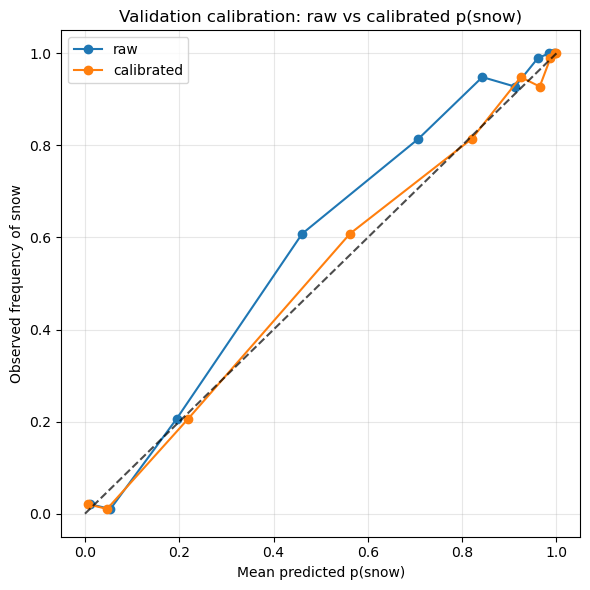

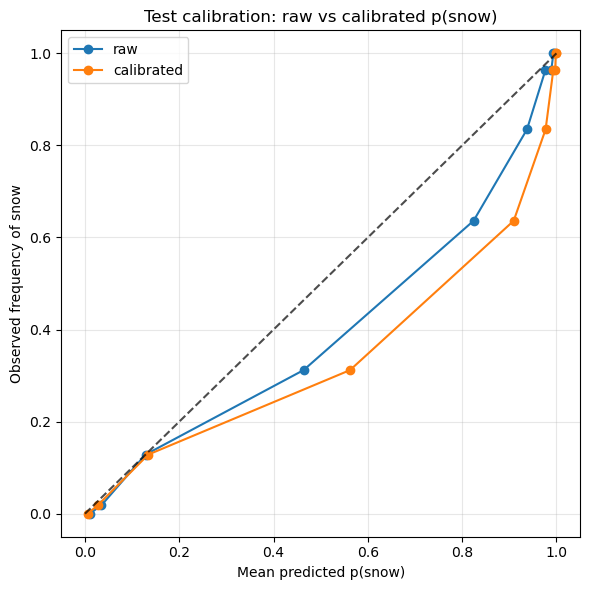

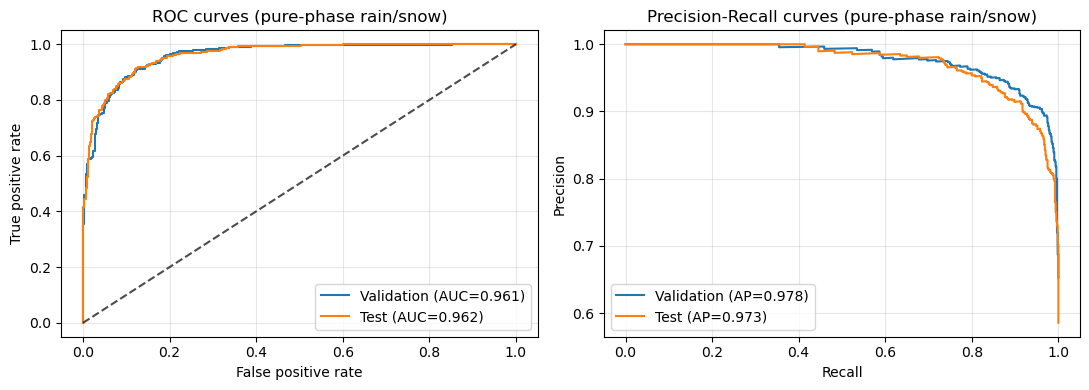

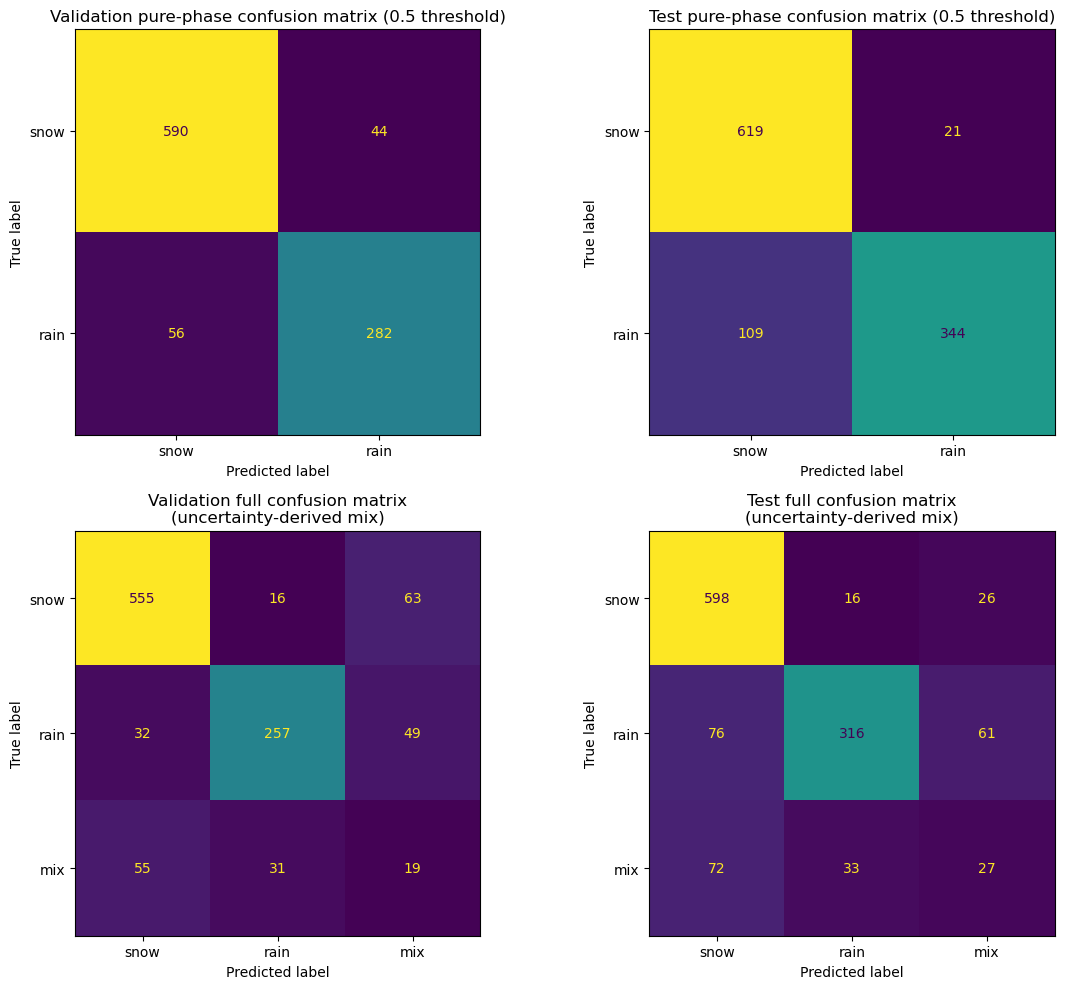

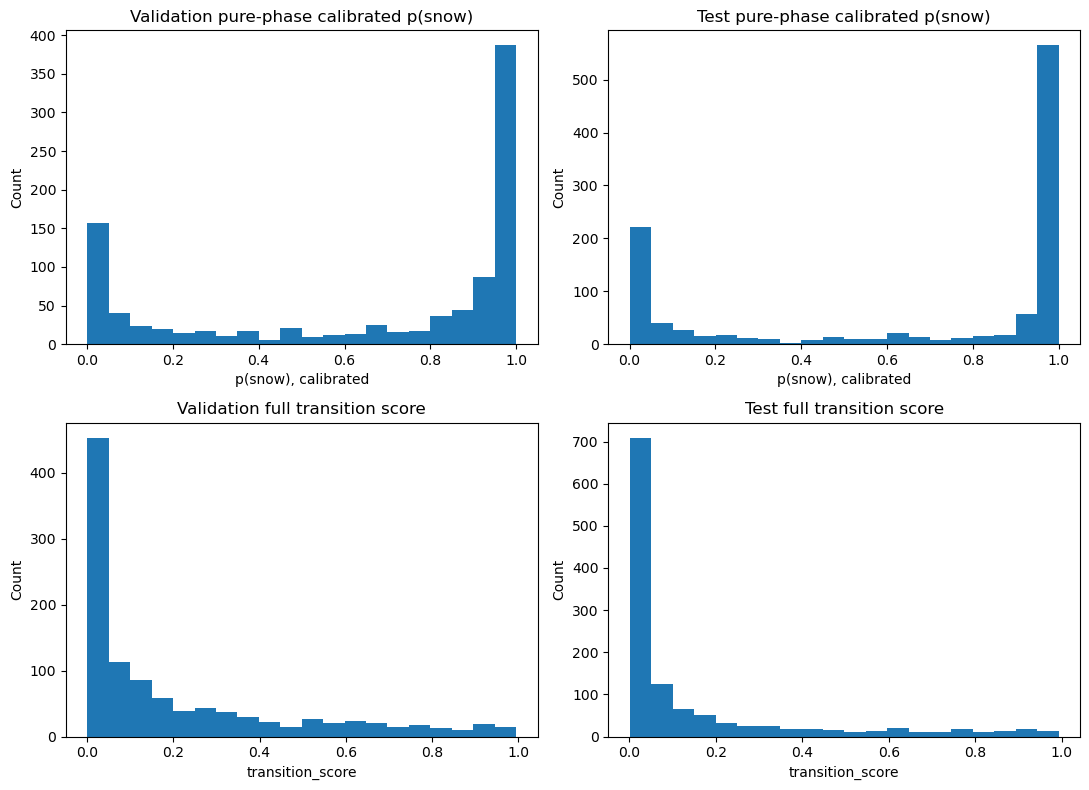

,conf_bin,n,accuracy,mean_confidence
0,"(0.499, 0.6]",47,0.446809,0.545412
1,"(0.6, 0.7]",65,0.600000,0.651985
2,"(0.7, 0.8]",65,0.784615,0.750330
3,"(0.8, 0.9]",124,0.846774,0.853297
4,"(0.9, 1.0]",671,0.977645,0.975192


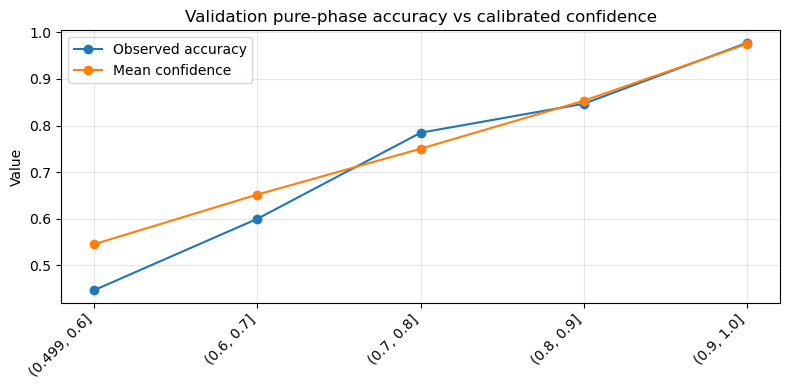

,conf_bin,n,accuracy,mean_confidence
0,"(0.499, 0.6]",41,0.560976,0.547283
1,"(0.6, 0.7]",46,0.565217,0.648140
2,"(0.7, 0.8]",47,0.595745,0.757273
3,"(0.8, 0.9]",77,0.766234,0.858735
4,"(0.9, 1.0]",882,0.937642,0.982697


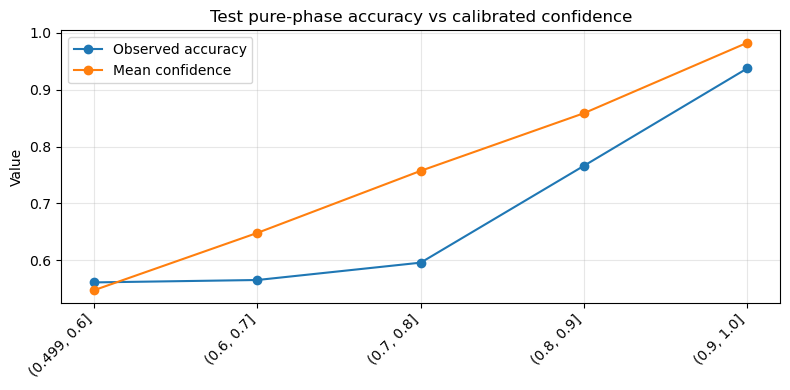

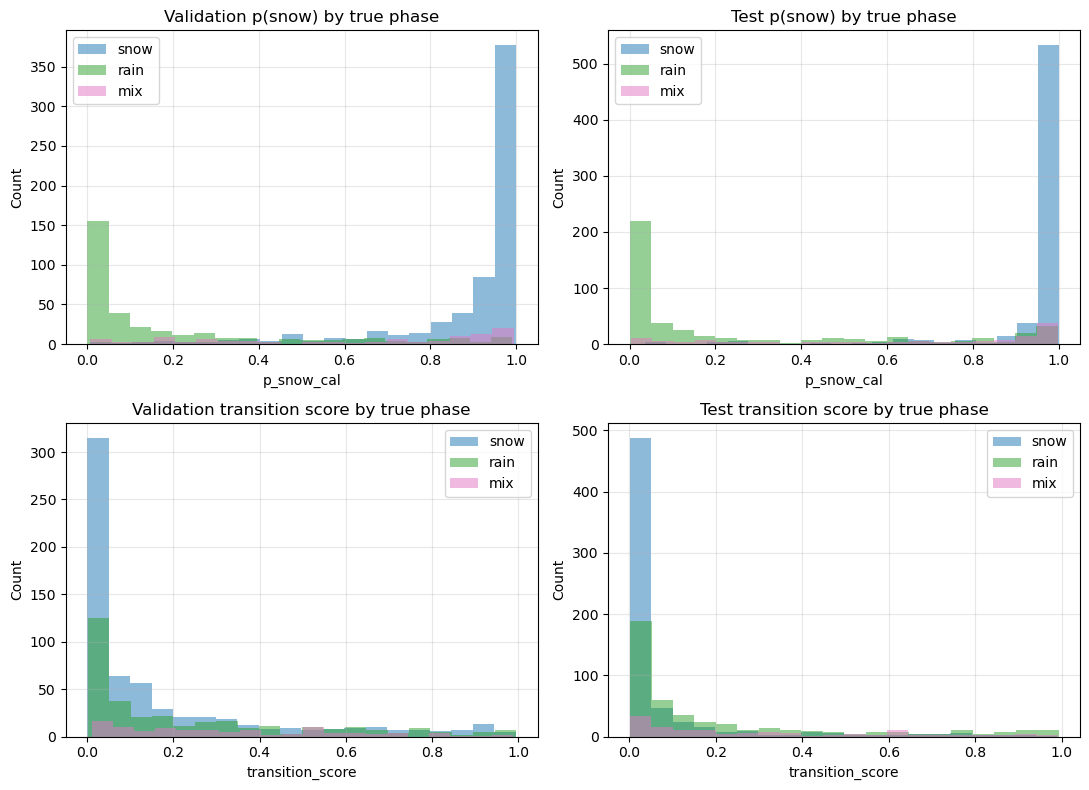


=== Validation | near_freezing_air_1C | uncertainty-derived 3-class report ===
              precision    recall  f1-score   support

        snow     0.8690    0.9542    0.9097       153
        rain     0.0000    0.0000    0.0000        15
         mix     0.0769    0.0714    0.0741        14

    accuracy                         0.8077       182
   macro avg     0.3153    0.3419    0.3279       182
weighted avg     0.7365    0.8077    0.7704       182


=== Validation | near_freezing_wet_1C | uncertainty-derived 3-class report ===
              precision    recall  f1-score   support

        snow     0.7778    0.8270    0.8016       237
        rain     0.7953    0.6392    0.7088       158
         mix     0.1772    0.2222    0.1972        63

    accuracy                         0.6790       458
   macro avg     0.5834    0.5628    0.5692       458
weighted avg     0.7012    0.6790    0.6865       458


=== Test | near_freezing_air_1C | uncertainty-derived 3-class report ===
    

In [18]:
# =============================================================================
# VALIDATION / TEST METRICS AND VISUALS
# =============================================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

PHASE_COLORS = {
    "snow": "#1f77b4",   # blue
    "rain": "#2ca02c",   # green
    "mix":  "#e377c2",   # pink
}


def summarize_binary_probability_metrics(y_true_bin, p_raw, p_cal, name: str) -> None:
    print(f"\n=== {name} | PURE-PHASE BINARY PROBABILITY METRICS ===")
    print(f"ROC AUC (raw/cal):         {roc_auc_score(y_true_bin, p_raw):.4f} / {roc_auc_score(y_true_bin, p_cal):.4f}")
    print(f"Average precision:        {average_precision_score(y_true_bin, p_cal):.4f}")
    print(f"Brier score (raw/cal):    {brier_score_loss(y_true_bin, p_raw):.4f} / {brier_score_loss(y_true_bin, p_cal):.4f}")
    print(f"Log loss (raw/cal):       {log_loss(y_true_bin, p_raw, labels=[0,1]):.4f} / {log_loss(y_true_bin, p_cal, labels=[0,1]):.4f}")


def summarize_binary_hard_metrics(y_true_phase, y_pred_phase, name: str) -> None:
    print(f"\n=== {name} | PURE-PHASE HARD BINARY METRICS (0.5 THRESHOLD) ===")
    print(f"Accuracy:          {accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Macro F1:          {f1_score(y_true_phase, y_pred_phase, average='macro'):.4f}")
    print(classification_report(
        y_true_phase,
        y_pred_phase,
        labels=[SNOW_CODE, RAIN_CODE],
        target_names=["snow", "rain"],
        digits=4,
        zero_division=0,
    ))


def summarize_uncertainty_phase_metrics(y_true_phase, y_pred_phase, name: str) -> None:
    print(f"\n=== {name} | UNCERTAINTY-DERIVED 3-CLASS METRICS ===")
    print(f"Accuracy:          {accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Macro F1:          {f1_score(y_true_phase, y_pred_phase, average='macro'):.4f}")
    print(classification_report(
        y_true_phase,
        y_pred_phase,
        labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
        target_names=FULL_CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))


def summarize_mix_uncertainty_behavior(y_true_phase, y_pred_phase, dataset_name: str) -> None:
    y_true_phase = np.asarray(y_true_phase)
    y_pred_phase = np.asarray(y_pred_phase)

    true_mix = y_true_phase == MIX_CODE
    true_pure = np.isin(y_true_phase, [SNOW_CODE, RAIN_CODE])
    pred_mix = y_pred_phase == MIX_CODE
    pred_conf = y_pred_phase != MIX_CODE

    mix_capture = pred_mix[true_mix].mean() if true_mix.any() else np.nan
    pure_coverage = pred_conf[true_pure].mean() if true_pure.any() else np.nan
    pure_conf_acc = (y_pred_phase[true_pure & pred_conf] == y_true_phase[true_pure & pred_conf]).mean() if np.any(true_pure & pred_conf) else np.nan
    confident_fraction_all = pred_conf.mean()

    print(f"\n=== {dataset_name} | MIX / UNCERTAINTY BEHAVIOR ===")
    print(f"True-mix capture rate:            {mix_capture:.4f}")
    print(f"Pure-phase confident coverage:    {pure_coverage:.4f}")
    print(f"Pure-phase confident accuracy:    {pure_conf_acc:.4f}")
    print(f"Overall confident prediction frac:{confident_fraction_all:.4f}")


def plot_calibration_comparison(y_true_bin, p_raw, p_cal, title: str) -> None:
    frac_raw, mean_raw = calibration_curve(y_true_bin, p_raw, n_bins=10, strategy="quantile")
    frac_cal, mean_cal = calibration_curve(y_true_bin, p_cal, n_bins=10, strategy="quantile")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(mean_raw, frac_raw, marker="o", label="raw")
    ax.plot(mean_cal, frac_cal, marker="o", label="calibrated")
    ax.plot([0, 1], [0, 1], "--", color="k", alpha=0.7)
    ax.set_xlabel("Mean predicted p(snow)")
    ax.set_ylabel("Observed frequency of snow")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_confidence_vs_accuracy(df_pred: pd.DataFrame, title: str) -> None:
    work = df_pred.copy()
    work["correct_binary05"] = (work["prediction_binary05"] == work["phase_full"]).astype(int)
    work["confidence"] = np.maximum(work["p_snow_cal"], work["p_rain_cal"])
    bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    work["conf_bin"] = pd.cut(work["confidence"], bins=bins, include_lowest=True)

    summary = (
        work.groupby("conf_bin", observed=False)
        .agg(
            n=("correct_binary05", "size"),
            accuracy=("correct_binary05", "mean"),
            mean_confidence=("confidence", "mean"),
        )
        .reset_index()
    )

    display(summary)

    plt.figure(figsize=(8, 4))
    plt.plot(summary["conf_bin"].astype(str), summary["accuracy"], marker="o", label="Observed accuracy")
    plt.plot(summary["conf_bin"].astype(str), summary["mean_confidence"], marker="o", label="Mean confidence")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# Validation diagnostics (probabilities + uncertainty product)
# ---------------------------------------------------------------------
y_val_bin = y_val.to_numpy()
y_test_bin = y_test.to_numpy()

summarize_binary_probability_metrics(y_val_bin, val_fit_prob_raw, val_fit_prob_cal, "Validation")
summarize_binary_probability_metrics(y_test_bin, test_fit_prob_raw, test_fit_prob_cal, "Test")

summarize_binary_hard_metrics(y_val_fit_phase, val_fit_pred_binary05, "Validation")
summarize_binary_hard_metrics(y_test_fit_phase, test_fit_pred_binary05, "Test")

summarize_uncertainty_phase_metrics(y_val_full_phase, val_full_pred_phase, "Validation")
summarize_uncertainty_phase_metrics(y_test_full_phase, test_full_pred_phase, "Test")

summarize_mix_uncertainty_behavior(y_val_full_phase, val_full_pred_phase, "Validation")
summarize_mix_uncertainty_behavior(y_test_full_phase, test_full_pred_phase, "Test")

# ---------------------------------------------------------------------
# Calibration curves: raw vs calibrated on pure-phase subsets
# ---------------------------------------------------------------------
plot_calibration_comparison(
    y_val_bin,
    val_fit_prob_raw,
    val_fit_prob_cal,
    title="Validation calibration: raw vs calibrated p(snow)",
)

plot_calibration_comparison(
    y_test_bin,
    test_fit_prob_raw,
    test_fit_prob_cal,
    title="Test calibration: raw vs calibrated p(snow)",
)

# ---------------------------------------------------------------------
# ROC / PR curves on pure-phase subsets
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for y_true_bin, p_cal, label in [
    (y_val_bin, val_fit_prob_cal, "Validation"),
    (y_test_bin, test_fit_prob_cal, "Test"),
]:
    fpr, tpr, _ = roc_curve(y_true_bin, p_cal)
    prec, rec, _ = precision_recall_curve(y_true_bin, p_cal)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_true_bin, p_cal):.3f})")
    axes[1].plot(rec, prec, label=f"{label} (AP={average_precision_score(y_true_bin, p_cal):.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="k", alpha=0.7)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves (pure-phase rain/snow)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (pure-phase rain/snow)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Confusion matrices
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cm_val_bin = confusion_matrix(y_val_fit_phase, val_fit_pred_binary05, labels=[SNOW_CODE, RAIN_CODE])
ConfusionMatrixDisplay(cm_val_bin, display_labels=["snow", "rain"]).plot(ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Validation pure-phase confusion matrix (0.5 threshold)")

cm_test_bin = confusion_matrix(y_test_fit_phase, test_fit_pred_binary05, labels=[SNOW_CODE, RAIN_CODE])
ConfusionMatrixDisplay(cm_test_bin, display_labels=["snow", "rain"]).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title("Test pure-phase confusion matrix (0.5 threshold)")

cm_val_unc = confusion_matrix(y_val_full_phase, val_full_pred_phase, labels=[SNOW_CODE, RAIN_CODE, MIX_CODE])
ConfusionMatrixDisplay(cm_val_unc, display_labels=FULL_CLASS_NAMES).plot(ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("Validation full confusion matrix\n(uncertainty-derived mix)")

cm_test_unc = confusion_matrix(y_test_full_phase, test_full_pred_phase, labels=[SNOW_CODE, RAIN_CODE, MIX_CODE])
ConfusionMatrixDisplay(cm_test_unc, display_labels=FULL_CLASS_NAMES).plot(ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("Test full confusion matrix\n(uncertainty-derived mix)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Probability / uncertainty distributions
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(df_val_fit["p_snow_cal"], bins=20)
axes[0, 0].set_title("Validation pure-phase calibrated p(snow)")
axes[0, 0].set_xlabel("p(snow), calibrated")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df_test_fit["p_snow_cal"], bins=20)
axes[0, 1].set_title("Test pure-phase calibrated p(snow)")
axes[0, 1].set_xlabel("p(snow), calibrated")
axes[0, 1].set_ylabel("Count")

axes[1, 0].hist(df_val_full["transition_score"], bins=20)
axes[1, 0].set_title("Validation full transition score")
axes[1, 0].set_xlabel("transition_score")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(df_test_full["transition_score"], bins=20)
axes[1, 1].set_title("Test full transition score")
axes[1, 1].set_xlabel("transition_score")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Confidence vs accuracy on pure-phase subsets
# ---------------------------------------------------------------------
plot_confidence_vs_accuracy(df_val_fit, "Validation pure-phase accuracy vs calibrated confidence")
plot_confidence_vs_accuracy(df_test_fit, "Test pure-phase accuracy vs calibrated confidence")

# ---------------------------------------------------------------------
# Probability and transition score by true phase (full sets)
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, df_, title, col in [
    (axes[0, 0], df_val_full, "Validation p(snow) by true phase", "p_snow_cal"),
    (axes[0, 1], df_test_full, "Test p(snow) by true phase", "p_snow_cal"),
    (axes[1, 0], df_val_full, "Validation transition score by true phase", "transition_score"),
    (axes[1, 1], df_test_full, "Test transition score by true phase", "transition_score"),
]:
    for code, cname in zip([SNOW_CODE, RAIN_CODE, MIX_CODE], FULL_CLASS_NAMES):
        vals = df_.loc[df_["phase_full"] == code, col]
        ax.hist(vals, bins=20, alpha=0.5, label=cname, color=PHASE_COLORS[cname])
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Near-freezing subset summaries for the full uncertainty-derived product
# ---------------------------------------------------------------------
for name, df_ in [("Validation", df_val_full), ("Test", df_test_full)]:
    for flag in ["near_freezing_air_1C", "near_freezing_wet_1C"]:
        sub = df_[df_[flag]].copy()
        if sub.empty:
            continue
        print(f"\n=== {name} | {flag} | uncertainty-derived 3-class report ===")
        print(classification_report(
            sub["phase_full"],
            sub["prediction_phase_uncertainty"],
            labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
            target_names=FULL_CLASS_NAMES,
            digits=4,
            zero_division=0,
        ))
